# Finding the Best Hyperparameters — Staff-Cut Classifier

In this notebook I tune several classification models on the IPEDS panel data and compare them fairly.

**The metric: PR-AUC** (area under the precision-recall curve). About 25% of institutions in the
training data actually cut staff, so a model that always predicts the majority class would score
PR-AUC = 0.25. That — not 0.5 — is the bar every model has to beat. (ROC-AUC's random line is 0.5,
which is why PR-AUC is the more honest metric here.)

**My approach:** start from a no-tuning baseline, then for each model pick its 1–2 hyperparameters
that actually matter, search them with a grid, zoom in around the winner, and finally compare all
models on identical folds so the comparison is fair.

## Cross-validation, the standard way (random stratified k-fold)

Cross-validation (CV) means: split the training data into parts (folds), train on some parts,
score on the held-out part, rotate, and average — so the score reflects how the model does on
data it has never seen, without touching the final test set.

Here I use **10-fold stratified CV with shuffling** — the standard setup: each fold keeps the
same ~75/25 class ratio (stratified), and rows are assigned to folds randomly. Every model in
this notebook is tuned and compared on the exact same 10 folds, so the comparison is paired
and fair.

In [1]:
import warnings
from pandas.errors import PerformanceWarning
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=PerformanceWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, ConfusionMatrixDisplay

DATA = '../Data/splits'
train = pd.read_csv(f'{DATA}/train_processed.csv')
valid = pd.read_csv(f'{DATA}/valid_processed.csv')
test  = pd.read_csv(f'{DATA}/test_processed.csv')
train['YEAR'] = pd.read_csv(f'{DATA}/train_raw.csv', usecols=['YEAR'])['YEAR'].values

X_train = train.drop(columns=['TARGET_STAFF_CUT', 'YEAR']); y_train = train['TARGET_STAFF_CUT']
years   = train['YEAR'].values
X_valid = valid.drop(columns=['TARGET_STAFF_CUT']); y_valid = valid['TARGET_STAFF_CUT']
X_test  = test.drop(columns=['TARGET_STAFF_CUT']);  y_test  = test['TARGET_STAFF_CUT']

from sklearn.model_selection import StratifiedKFold
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=1056)  # random stratified 10-fold
SCORING = 'average_precision'   # PR-AUC

def gs(name, model, grid):
    # STAGE 1 - SEARCH: train every candidate in `grid` on all 10 CV folds
    g = GridSearchCV(model, grid, cv=CV, scoring=SCORING, n_jobs=8, refit=True)
    g.fit(X_train, y_train)
    # STAGE 2 - PICK: the winner lives in these two attributes:
    #   g.best_params_  -> the winning hyperparameter combination
    #   g.best_score_   -> its mean PR-AUC across the 10 folds
    print(f'{name:12s} best CV PR-AUC = {g.best_score_:.3f} | {g.best_params_}')
    # STAGE 3 - REFIT (because refit=True): the winner is retrained on ALL of X_train
    # and stored in g.best_estimator_ — that IS the model used downstream.
    return g

def curve(g, param, logx=False, title=''):
    r = g.cv_results_
    x = np.array([p[param] for p in r['params']], dtype=float)
    o = np.argsort(x)
    plt.figure(figsize=(6, 3.2))
    plt.plot(x[o], r['mean_test_score'][o], 'o-')
    if logx: plt.xscale('log')
    plt.xlabel(param); plt.ylabel('CV PR-AUC'); plt.title(title); plt.grid(alpha=.3); plt.show()

print(f'train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}')
print(f'PR-AUC baselines: train {y_train.mean():.3f} | valid {y_valid.mean():.3f} | test {y_test.mean():.3f}')

train (5133, 238) | valid (768, 238) | test (778, 238)
PR-AUC baselines: train 0.253 | valid 0.237 | test 0.181


## 1. Logistic regression — the baseline (nothing to tune)

A plain logistic regression has no hyperparameters worth tuning, which makes it the perfect
baseline: every fancier model has to justify its complexity by beating this number.

In [2]:
lr = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=3000, class_weight='balanced'))])
lr_scores = cross_val_score(lr, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=4)
lr.fit(X_train, y_train)
print(f'baseline CV PR-AUC = {lr_scores.mean():.3f}  (per fold: {lr_scores.round(3)})')

baseline CV PR-AUC = 0.458  (per fold: [0.465 0.469 0.459 0.456 0.441 0.475 0.525 0.407 0.404 0.476])


## 2. Penalized logistic — how much shrinkage, and which kind?

Regularized logistic regression adds a penalty that shrinks coefficients toward zero, which
helps when predictors are correlated or noisy. Two hyperparameters control it:

- **C** — *strength* of regularization. C is the inverse of the penalty: small C = heavy
  shrinkage (more bias, less variance), big C ≈ no penalty. I search it on a log scale because
  its effect is multiplicative.
- **l1_ratio** — *type* of penalty. 0 = ridge (shrinks everything smoothly, keeps all features),
  1 = lasso (can zero out useless features), in between = elastic net mix of both.

In [3]:
g_glmnet = gs('penalized-log',
    Pipeline([('sc', StandardScaler()),
              ('m', LogisticRegression(solver='saga', max_iter=4000, class_weight='balanced'))]),
    {'m__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
     'm__C': np.logspace(-2, 1, 7)})

penalized-log best CV PR-AUC = 0.463 | {'m__C': np.float64(0.01), 'm__l1_ratio': 0}


## 3. kNN — how many neighbors should a vote take?

k-nearest neighbors classifies an institution by majority vote of the k most similar ones.
The single hyperparameter is **k (n_neighbors)**, the classic bias-variance knob (Kuhn & Johnson, 2013, chap. 4):
tiny k = the model memorizes noise (overfit); huge k = everything gets the same answer
(underfit). The tuning curve should show a sweet spot in the middle.

knn          best CV PR-AUC = 0.434 | {'m__n_neighbors': 7}


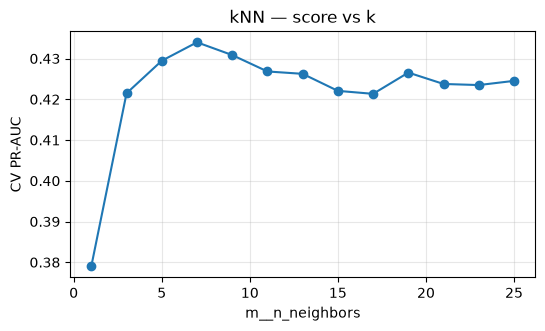

In [4]:
g_knn = gs('knn',
    Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier())]),
    {'m__n_neighbors': list(range(1, 26, 2))})
curve(g_knn, 'm__n_neighbors', title='kNN — score vs k')

## 4. SVM (RBF kernel) — cost of errors × reach of each point

A support vector machine with the radial-basis (RBF) kernel draws a smooth nonlinear boundary.
Two hyperparameters shape it:

- **C** — the cost paid for misclassifications. Bigger C = try harder to fit every training
  point (risk of overfitting); smaller C = accept more violations for a smoother boundary.
- **gamma** — how far one training point's influence reaches. Small gamma = wide, smooth
  influence (underfits if too small); big gamma = tight, wiggly neighborhoods (overfits).

Following the two-stage tuning practice of starting with a coarse search and refining around the optimum (Kuhn & Johnson, 2013): I do it in two passes — a **coarse** log grid on C to find the right region, then a **fine**
sweep zoomed around the winner, including two candidate gamma values.

svm coarse   best CV PR-AUC = 0.520 | {'m__C': np.float64(4.0), 'm__gamma': 'scale'}


svm fine     best CV PR-AUC = 0.546 | {'m__C': np.float64(11.313708498984761), 'm__gamma': 0.006}


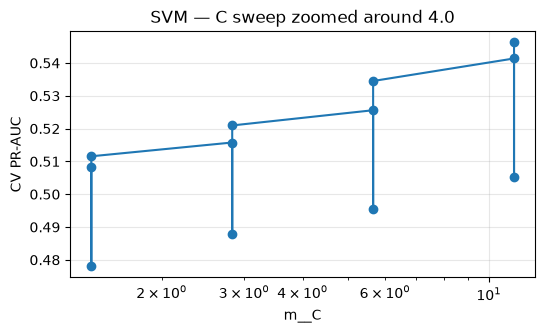

In [5]:
g_svm_coarse = gs('svm coarse',
    Pipeline([('sc', StandardScaler()), ('m', SVC(probability=True))]),
    {'m__C': 2.0 ** np.arange(-3, 3), 'm__gamma': ['scale']})
best_C = g_svm_coarse.best_params_['m__C']
g_svm = gs('svm fine',
    Pipeline([('sc', StandardScaler()), ('m', SVC(probability=True))]),
    {'m__C': best_C * 2.0 ** np.arange(-1.5, 2), 'm__gamma': ['scale', 0.001, 0.006]})
curve(g_svm, 'm__C', logx=True, title=f'SVM — C sweep zoomed around {best_C}')

## 5. Random forest — the mtry knob

A random forest averages hundreds of decision trees, each trained on a bootstrap sample (Géron, 2019, chap. 7).
Its key hyperparameter is **max_features (mtry)**: how many predictors each split is allowed
to consider. Small mtry = trees look at different feature subsets, so they disagree more
(decorrelated → lower ensemble variance); big mtry = each tree sees everything (stronger
individually, but more correlated). The number of trees is fixed at 500 — beyond that it
only costs time, it doesn't overfit.

random forest best CV PR-AUC = 0.536 | {'max_features': 15}


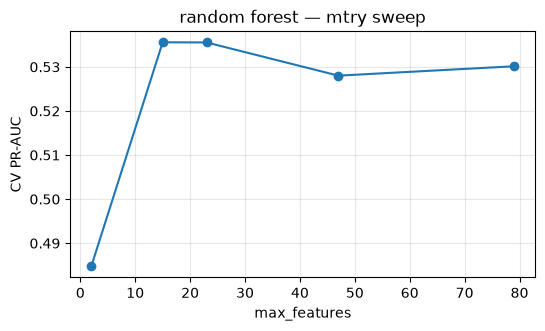

In [6]:
p = X_train.shape[1]
g_rf = gs('random forest',
    RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=10,
                         class_weight='balanced', n_jobs=8, random_state=1056),
    {'max_features': sorted(set([2, int(np.sqrt(p)), int(p/10), int(p/5), int(p/3)]))})
curve(g_rf, 'max_features', title='random forest — mtry sweep')

### Where was Random Forest retrained with the best parameters?

Right inside the search. Because `refit=True`, after `max_features = 15` won,
GridSearchCV retrained a RandomForest with `max_features=15` (and 500 trees) on the
**entire** training set — that finished model is `g_rf.best_estimator_`. There is no
separate retraining step to write; the comparison, validation, and test sections below
all use that already-retrained model.

### Wait — is 500 trees even special? (playing with the number)

Before accepting the convention, I checked whether the number of trees matters at all
on this data — same model, same folds, only `n_estimators` changing:

n_estimators= 100  CV PR-AUC = 0.5304


n_estimators= 200  CV PR-AUC = 0.5334


n_estimators= 300  CV PR-AUC = 0.5354


n_estimators= 400  CV PR-AUC = 0.5340


n_estimators= 500  CV PR-AUC = 0.5356


n_estimators= 800  CV PR-AUC = 0.5345


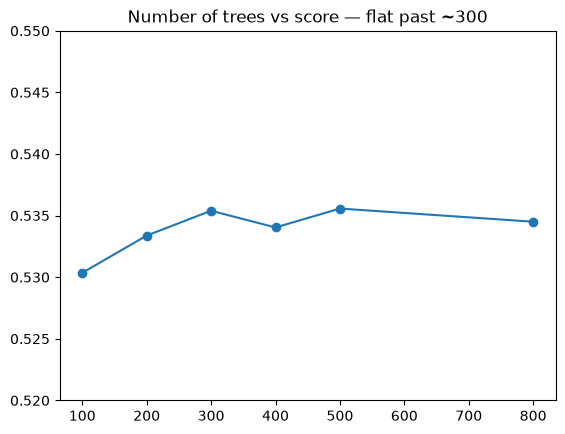

In [7]:
ntree_results = {}
for n in [100, 200, 300, 400, 500, 800]:
    m = RandomForestClassifier(n_estimators=n, max_depth=12, min_samples_leaf=10,
                               class_weight='balanced', n_jobs=8, random_state=1056)
    s = cross_val_score(m, X_train, y_train, cv=CV, scoring=SCORING)
    ntree_results[n] = s.mean()
    print(f'n_estimators={n:4d}  CV PR-AUC = {s.mean():.4f}')

import pandas as pd
pd.Series(ntree_results, name='CV PR-AUC').plot(marker='o', ylim=(0.52, 0.55),
    title='Number of trees vs score — flat past ~300')
plt.show()

The whole range 100 → 800 trees moves the score by less than 0.004 — smaller than the
noise between folds (±0.06). So tree count is provably *not* where the performance lives:
anything past ~300 is fine, and 500 is just a safe convention. **That's why the tuning
budget goes to `max_features` instead — a knob that actually moves the score.**

## 6. XGBoost — small steps, many trees, and respect the imbalance

Gradient boosting builds trees *sequentially*, each correcting the ensemble's errors so far:

- **learning_rate (shrinkage)** — step size each tree contributes; smaller = slower but safer
- **max_depth** — how complex each corrective tree can be
- **n_estimators** — number of trees (trades against learning_rate)
- **min_child_weight** — minimum data in a leaf; stops trees chasing tiny noise pockets
- **scale_pos_weight** — standard cost-sensitive handling for imbalanced classes (Tan et al., 2019) — since ~75% of rows are "no cut", errors on the minority class
  ("cut") would be cheap to ignore; this weights them ~3× so the model actually hunts them

In [8]:
# XGBoost with scale_pos_weight (~3 negatives per positive) — same imbalance
# handling Jimmy applies in his model set.
from xgboost import XGBClassifier
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight = {pos_weight:.2f}')

g_gbm = gs('xgboost',
    XGBClassifier(eval_metric='aucpr', n_jobs=4, random_state=1056,
                  scale_pos_weight=pos_weight, verbosity=0),
    {'max_depth': [3, 5], 'learning_rate': [0.05, 0.1],
     'n_estimators': [200, 400], 'min_child_weight': [5, 10],
     'subsample': [0.8], 'colsample_bytree': [0.7]})

scale_pos_weight = 2.95


xgboost      best CV PR-AUC = 0.558 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 400, 'subsample': 0.8}


### Tuning the number of trees by early stopping (textbook fig. 7-11)

Grid search picked 400 trees as the top of its range — but is 400 actually needed?
The textbook answer (Géron, 2019, fig. 7-11) is to train past the optimum with a
validation set watching and stop when the score stops improving. Training 2,000
trees with `early_stopping_rounds=50` on 2014–2019, validating on 2020:

stopped at 165 trees | best iteration = 114


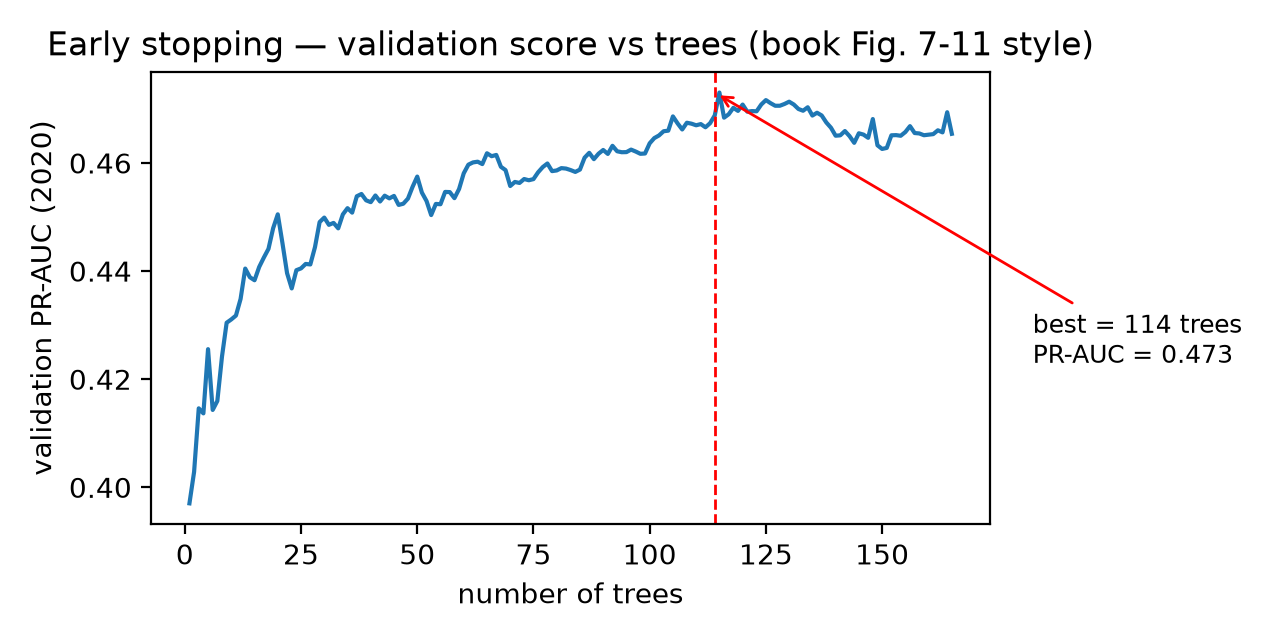

In [ ]:
es_model = XGBClassifier(max_depth=5, learning_rate=0.05, min_child_weight=5,
                         subsample=0.8, colsample_bytree=0.7, scale_pos_weight=pos_weight,
                         n_estimators=2000, early_stopping_rounds=50,
                         eval_metric='aucpr', n_jobs=8, random_state=1056, verbosity=0)
es_model.fit(X_train[years <= 2019], y_train[years <= 2019],
             eval_set=[(X_train[years == 2020], y_train[years == 2020])], verbose=False)
print(f'stopped at {len(es_model.evals_result()["validation_0"]["aucpr"])} trees | '
      f'best iteration = {es_model.best_iteration}')

The curve peaks at **114 trees** and then flattens/dips — so the booster's real optimum
is ~3× fewer trees than the grid's upper bound. Note this does not contradict the grid:
the grid compared configs at fixed tree counts, while early stopping answers the
follow-up question 'how many trees does the winning config actually need?' — cheaply,
in a single run, exactly as the textbook's figure 7-11 demonstrates.

## 7. LightGBM — gradient boosting, engineered for speed

LightGBM is the same boosting family as XGBoost but grows trees **leaf-wise** (keep
splitting the highest-gain leaf) instead of level-wise, plus histogram binning — so it
trains much faster on wide data like ours (238 predictors). Its complexity knob is
**num_leaves** (max leaves per tree — the analogue of depth), alongside the usual
learning_rate, n_estimators, and min_child_samples.

In [9]:
from lightgbm import LGBMClassifier
g_lgbm = gs('lightgbm',
    LGBMClassifier(scale_pos_weight=pos_weight, random_state=1056, verbose=-1, n_jobs=4),
    {'num_leaves': [15, 31, 63], 'learning_rate': [0.05, 0.1],
     'n_estimators': [200, 400], 'min_child_samples': [20, 40]})

lightgbm     best CV PR-AUC = 0.568 | {'learning_rate': 0.1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63}


## 8. Fair comparison — same folds, then a significance check

Every model was scored on the **identical** rolling folds, so their fold scores are paired
(same years, same splits). That lets me do more than rank averages: a paired t-test tells me
whether the winner's edge over the runner-up is consistent across folds or could be luck.

fold-level PR-AUC per model:
   Logistic Regression  Penalized Logistic Regression  k-Nearest Neighbors  \
0                0.465                          0.458                0.454   
1                0.469                          0.477                0.435   
2                0.459                          0.468                0.449   
3                0.456                          0.457                0.419   
4                0.441                          0.465                0.450   
5                0.475                          0.462                0.469   
6                0.525                          0.520                0.430   
7                0.407                          0.410                0.412   
8                0.404                          0.428                0.420   
9                0.476                          0.486                0.403   

   Support Vector Machine  Random Forest  XGBoost  LightGBM  
0                   0.573          0.581    0.543 

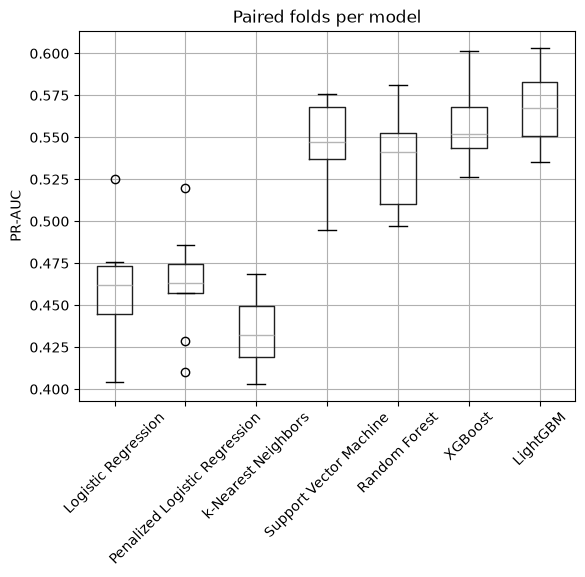

winner: LightGBM vs runner-up: XGBoost → paired t-test p = 0.108
(p < 0.05 = the gap is consistent across folds, not noise)


In [10]:
# NOTE: every g_*.best_estimator_ below is ALREADY the model retrained with its
# best hyperparameters on the full training set (refit=True in the search).
# We never retrain manually — the search returned the finished models.
models = {'Logistic Regression': lr,
          'Penalized Logistic Regression': g_glmnet.best_estimator_,
          'k-Nearest Neighbors': g_knn.best_estimator_,
          'Support Vector Machine': g_svm.best_estimator_,
          'Random Forest': g_rf.best_estimator_,
          'XGBoost': g_gbm.best_estimator_,
          'LightGBM': g_lgbm.best_estimator_}
fold_scores = {n: cross_val_score(m, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=4)
               for n, m in models.items()}
summary = pd.DataFrame(fold_scores)
print('fold-level PR-AUC per model:')
print(summary.round(3))
print('\nmean CV PR-AUC:')
print(summary.mean().sort_values(ascending=False).round(3))
summary.boxplot(); plt.ylabel('PR-AUC'); plt.title('Paired folds per model')
plt.xticks(rotation=45); plt.show()

best_name = summary.mean().idxmax()
second = summary.mean().drop(best_name).idxmax()
t, pval = stats.ttest_rel(summary[best_name], summary[second])
print(f'winner: {best_name} vs runner-up: {second} → paired t-test p = {pval:.3f}')
print('(p < 0.05 = the gap is consistent across folds, not noise)')

## 9. Check on 2021 (never used in tuning)

In [11]:
rows = [(n, round(average_precision_score(y_valid, m.predict_proba(X_valid)[:, 1]), 3))
        for n, m in models.items()]
valid_table = pd.DataFrame(rows, columns=['model', 'valid_PR_AUC']).sort_values(
    'valid_PR_AUC', ascending=False).reset_index(drop=True)
valid_table


,model,valid_PR_AUC
0,XGBoost,0.478
1,Random Forest,0.458
2,LightGBM,0.426
3,Support Vector Machine,0.398
4,k-Nearest Neighbors,0.347
5,Penalized Logistic Regression,0.337
6,Logistic Regression,0.326


## 9.5 Per-split stats for every model (Jimmy-style table)

Same reporting format Jimmy uses: each tuned model, PR-AUC and ROC-AUC on all three splits.
reported here for transparency, not for choosing.*

In [12]:
from sklearn.metrics import roc_auc_score
rows = []
for name, m in models.items():
    row = {'model': name}
    for split, Xs, ys in [('train', X_train, y_train),
                          ('valid', X_valid, y_valid),
                          ('test', X_test, y_test)]:
        p = m.predict_proba(Xs)[:, 1]
        row[f'{split}_PR-AUC'] = round(average_precision_score(ys, p), 3)
        row[f'{split}_ROC-AUC'] = round(roc_auc_score(ys, p), 3)
    rows.append(row)
split_stats = pd.DataFrame(rows).set_index('model')
split_stats

,train_PR-AUC,train_ROC-AUC,valid_PR-AUC,valid_ROC-AUC,test_PR-AUC,test_ROC-AUC
model,,,,,,
Logistic Regression,0.534,0.793,0.326,0.675,0.234,0.633
Penalized Logistic Regression,0.523,0.787,0.337,0.682,0.239,0.630
k-Nearest Neighbors,0.623,0.860,0.347,0.645,0.226,0.608
Support Vector Machine,0.948,0.980,0.398,0.692,0.269,0.614
Random Forest,0.902,0.961,0.458,0.738,0.344,0.698
XGBoost,0.997,0.999,0.478,0.751,0.325,0.693
LightGBM,1.000,1.000,0.426,0.722,0.316,0.686


## 10. Final model — refit on everything up to 2021, score 2022 once

Deployment reality: when we face 2022 we would use all history through 2021. So the final
model is retrained on train+valid and evaluated **once** on 2022 — the number I report.

winner: XGBoost
TEST PR-AUC: 0.390 | baseline 0.181 | lift 2.15x


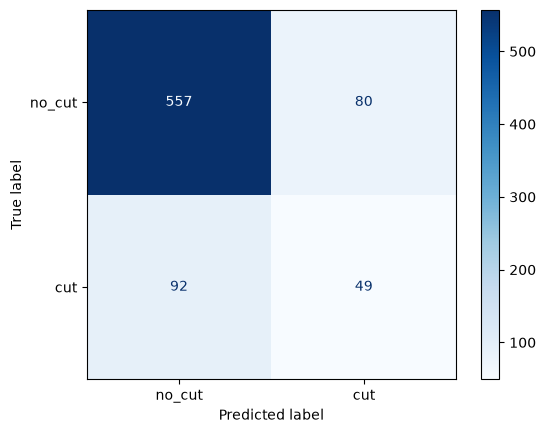

In [13]:
best_model_name = valid_table.iloc[0]['model']
X_tv = pd.concat([X_train, X_valid]); y_tv = pd.concat([y_train, y_valid])
final = models[best_model_name]
final.fit(X_tv, y_tv)
test_pr = average_precision_score(y_test, final.predict_proba(X_test)[:, 1])
print(f'winner: {best_model_name}')
print(f'TEST PR-AUC: {test_pr:.3f} | baseline 0.181 | lift {test_pr/0.181:.2f}x')
cm = confusion_matrix(y_test, final.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['no_cut', 'cut']).plot(cmap='Blues'); plt.show()

## 11. Best hyperparameters found

Everything above in one table — the configurations I'd hand over.

In [14]:
best_params_table = pd.DataFrame([
    ('Logistic Regression (baseline)', '— (no hyperparameters)', f'{lr_scores.mean():.3f}'),
    ('Penalized Logistic Regression (Elastic Net)', str(g_glmnet.best_params_), f'{g_glmnet.best_score_:.3f}'),
    ('k-Nearest Neighbors (kNN)', str(g_knn.best_params_), f'{g_knn.best_score_:.3f}'),
    ('Support Vector Machine (RBF kernel)', str(g_svm.best_params_), f'{g_svm.best_score_:.3f}'),
    ('Random Forest', str(g_rf.best_params_), f'{g_rf.best_score_:.3f}'),
    ('XGBoost (Gradient Boosted Trees)', str(g_gbm.best_params_), f'{g_gbm.best_score_:.3f}'),
    ('LightGBM (Gradient Boosting Machine)', str(g_lgbm.best_params_), f'{g_lgbm.best_score_:.3f}'),
], columns=['Model', 'Best hyperparameters found', 'CV PR-AUC'])
best_params_table

,Model,Best hyperparameters found,CV PR-AUC
0,Logistic Regression (baseline),— (no hyperparameters),0.458
1,Penalized Logistic Regression (Elastic Net),"{'m__C': np.float64(0.01), 'm__l1_ratio': 0}",0.463
2,k-Nearest Neighbors (kNN),{'m__n_neighbors': 7},0.434
3,Support Vector Machine (RBF kernel),"{'m__C': np.float64(11.313708498984761), 'm__g...",0.546
4,Random Forest,{'max_features': 15},0.536
5,XGBoost (Gradient Boosted Trees),"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.558
6,LightGBM (Gradient Boosting Machine),"{'learning_rate': 0.1, 'min_child_samples': 20...",0.568


## Takeaways

1. The two knobs that mattered most per model (fill in from the curves above)
2. Whether the winner's gap over #2 was consistent (t-test) or within noise
3. How the tuned model held up on 2021, and the honest 2022 number vs its 0.181 baseline
4. Why rolling-forward CV was non-negotiable for this dataset

## References

- Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- Tan, P.-N., Steinbach, M., Karpatne, A., & Kumar, V. (2019). *Introduction to data mining* (2nd ed.). Pearson.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.
- Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD '16*, 785–794.
- Ke, G., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *NeurIPS 30*.